# Notebook 7: Final Model Interpretation and Project Summary

## 1. Purpose

This notebook completes the diabetes glucose prediction project by interpreting the final tuned model and summarizing the overall project findings.

In previous notebooks, the dataset was cleaned, explored, prepared for modeling, and used to train baseline and tuned regression models. The goal of this notebook is not to build new models, but to explain the final model results clearly and connect them back to the project objective.

This notebook focuses on:

- Loading tuned model outputs
- Reviewing final model performance
- Interpreting MAE, RMSE, and R²
- Comparing actual vs predicted glucose values
- Analyzing residual errors
- Understanding feature importance
- Interpreting SHAP results if available
- Discussing model limitations
- Summarizing business and research conclusions
- Preparing final GitHub and README updates

# 2. Import Libraries and Universal Chart Styling

In [1]:
# Core libraries
import os
import warnings
import joblib
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


### Why this step is needed

This step imports all libraries required for loading saved model outputs, evaluating final predictions, and creating interpretation charts.

### Consequences if skipped

If these libraries are not imported, later cells may fail with errors such as `NameError`, `ModuleNotFoundError`, or missing plotting functions.

In [2]:
# Universal chart styling setup

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="husl"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

print("Universal chart styling applied.")

Universal chart styling applied.


### Why this step is needed

A universal chart style makes all visualizations consistent, professional, and easier to read.

### Consequences if skipped

Charts may look inconsistent across the notebook, making the final project appear less polished and less GitHub-ready.

# 3. Define Project Paths

In [3]:
# Define project paths

BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Figures directory:", FIGURES_DIR)

Base directory: c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks
Data directory: c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks\data\processed
Model directory: c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks\models
Figures directory: c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks\reports\figures


### Why this step is needed

Defining paths keeps the notebook organized and prevents repeated hard-coded file locations.

### Consequences if skipped

Files may be saved in the wrong location or the notebook may fail when moved to another computer or uploaded to GitHub.

# 4. Load Final Tuned Model Outputs

In [4]:
BASE_DIR = r"c:\Projects\DataAnalysis\diabetes-glucose-analysis"

# Correct directories
DATA_DIR = os.path.join(BASE_DIR, "reports")
MODEL_DIR = os.path.join(BASE_DIR, "models")

print("DATA_DIR:")
print(DATA_DIR)

print("\nMODEL_DIR:")
print(MODEL_DIR)

DATA_DIR:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports

MODEL_DIR:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\models


In [5]:
print(os.listdir(DATA_DIR))

['baseline_best_model_predictions.csv', 'baseline_model_feature_list.csv', 'baseline_model_results.csv', 'figures', 'final_report.md', 'tuned_model_feature_list.csv', 'tuned_model_predictions.csv', 'tuned_model_results.csv']


In [6]:
tuned_results_path = os.path.join(DATA_DIR, "tuned_model_results.csv")
tuned_predictions_path = os.path.join(DATA_DIR, "tuned_model_predictions.csv")
tuned_feature_list_path = os.path.join(DATA_DIR, "tuned_model_feature_list.csv")

model_path = os.path.join(MODEL_DIR, "final_tuned_random_forest_model.pkl")

tuned_results = pd.read_csv(tuned_results_path)
tuned_predictions = pd.read_csv(tuned_predictions_path)
tuned_features = pd.read_csv(tuned_feature_list_path)

final_model = joblib.load(model_path)

print("Files loaded successfully.")

Files loaded successfully.


### Why this step is needed

This step loads the final tuned model results, predictions, feature list, and saved model object from Notebook 6.

### Consequences if skipped

The notebook cannot interpret the final model because the required outputs would not be available.

# 5. Preview Loaded Files

In [7]:
# Preview tuned results

tuned_results.head()

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593
2,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
3,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593
4,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199


In [8]:
# Preview tuned predictions

tuned_predictions.head()

,actual_glucose,predicted_glucose,residual,absolute_error,error_category
0,85.333333,85.343934,-0.010600,0.010600,Low Error
1,121.000000,116.526660,4.473340,4.473340,Low Error
2,302.000000,301.010600,0.989400,0.989400,Low Error
3,91.000000,88.024835,2.975165,2.975165,Low Error
4,213.666667,216.043834,-2.377167,2.377167,Low Error


In [9]:
# Preview tuned feature list

tuned_features.head()

,feature_name
0,calories
1,heart_rate
2,glucose_lag_1
3,glucose_lag_3
4,glucose_lag_6


### Why this step is needed

Previewing the files confirms that the expected columns and values were loaded correctly.

### Consequences if skipped

Column name mismatches or incorrect file contents may go unnoticed until later cells fail.

In [10]:
print("Tuned results columns:")
print(tuned_results.columns.tolist())

print("\nTuned predictions columns:")
print(tuned_predictions.columns.tolist())

print("\nTuned feature list columns:")
print(tuned_features.columns.tolist())

Tuned results columns:
['model', 'MAE', 'RMSE', 'R2']

Tuned predictions columns:
['actual_glucose', 'predicted_glucose', 'residual', 'absolute_error', 'error_category']

Tuned feature list columns:
['feature_name']


### Why this step is needed

Column inspection helps confirm the exact column names before using them in analysis and visualizations.

### Consequences if skipped

You may get `KeyError` if you assume a column name that does not exist.

# 7. Standardize Prediction Column Names If Needed

In [11]:
# Make a copy for safe analysis

pred_df = tuned_predictions.copy()

# Display columns to manually verify
pred_df.columns

Index(['actual_glucose', 'predicted_glucose', 'residual', 'absolute_error',
       'error_category'],
      dtype='str')

In [12]:
# Rename columns only if needed

possible_actual_cols = ["actual_glucose", "y_true", "actual", "glucose"]
possible_pred_cols = ["predicted_glucose", "y_pred", "predicted", "prediction"]

actual_col = None
pred_col = None

for col in possible_actual_cols:
    if col in pred_df.columns:
        actual_col = col
        break

for col in possible_pred_cols:
    if col in pred_df.columns:
        pred_col = col
        break

print("Actual column detected:", actual_col)
print("Prediction column detected:", pred_col)

if actual_col is None or pred_col is None:
    raise ValueError("Could not automatically detect actual and predicted glucose columns. Please check pred_df.columns.")

pred_df = pred_df.rename(columns={
    actual_col: "actual_glucose",
    pred_col: "predicted_glucose"
})

pred_df.head()

Actual column detected: actual_glucose
Prediction column detected: predicted_glucose


,actual_glucose,predicted_glucose,residual,absolute_error,error_category
0,85.333333,85.343934,-0.010600,0.010600,Low Error
1,121.000000,116.526660,4.473340,4.473340,Low Error
2,302.000000,301.010600,0.989400,0.989400,Low Error
3,91.000000,88.024835,2.975165,2.975165,Low Error
4,213.666667,216.043834,-2.377167,2.377167,Low Error


### Why this step is needed

Different notebooks may save prediction columns using slightly different names. This step standardizes them for final analysis.

### Consequences if skipped

Later evaluation and charting code may fail if the column names do not exactly match.

# 8. Calculate Final Model Metrics

In [13]:
# Calculate final model metrics

y_true = pred_df["actual_glucose"]
y_pred = pred_df["predicted_glucose"]

final_mae = mean_absolute_error(y_true, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
final_r2 = r2_score(y_true, y_pred)

final_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [final_mae, final_rmse, final_r2]
})

final_metrics

,Metric,Value
0,MAE,1.508096
1,RMSE,3.504146
2,R2,0.996229


### Why this step is needed

This step calculates the final performance metrics from the saved tuned model predictions.

### Consequences if skipped

You would rely only on previously saved results without independently confirming the final model performance.

# 9. Interpret MAE, RMSE, and R²

## Final Model Performance Interpretation

The final tuned Random Forest model was evaluated using three regression metrics:

### Mean Absolute Error

MAE measures the average absolute difference between the actual glucose value and the predicted glucose value.

In this project, MAE represents the average prediction error in glucose units.

A lower MAE means the model is making predictions closer to the true glucose values.

### Root Mean Squared Error

RMSE also measures prediction error, but it penalizes larger errors more strongly than MAE.

If RMSE is much larger than MAE, it suggests that some predictions have large errors.

### R² Score

R² measures how much variation in glucose values is explained by the model.

A higher R² means the model explains more of the variation in glucose levels.

However, R² should not be interpreted alone. For healthcare-related prediction tasks, error size and clinical usefulness are also important.

In [14]:
print(f"Final Tuned Model MAE: {final_mae:.2f}")
print(f"Final Tuned Model RMSE: {final_rmse:.2f}")
print(f"Final Tuned Model R²: {final_r2:.4f}")

Final Tuned Model MAE: 1.51
Final Tuned Model RMSE: 3.50
Final Tuned Model R²: 0.9962


### Interpretation Summary

The final model should be interpreted based on both error size and explained variance.

If the MAE is reasonably low, the model is generally close to actual glucose values on average.

If RMSE is noticeably higher than MAE, the model may still struggle with certain high-error cases.

If R² is positive and reasonably strong, the model captures meaningful patterns in the data.

However, because glucose prediction is a time-sensitive health-related problem, even a statistically good model may still need more validation before practical use.

# 10. Plot Final Metrics

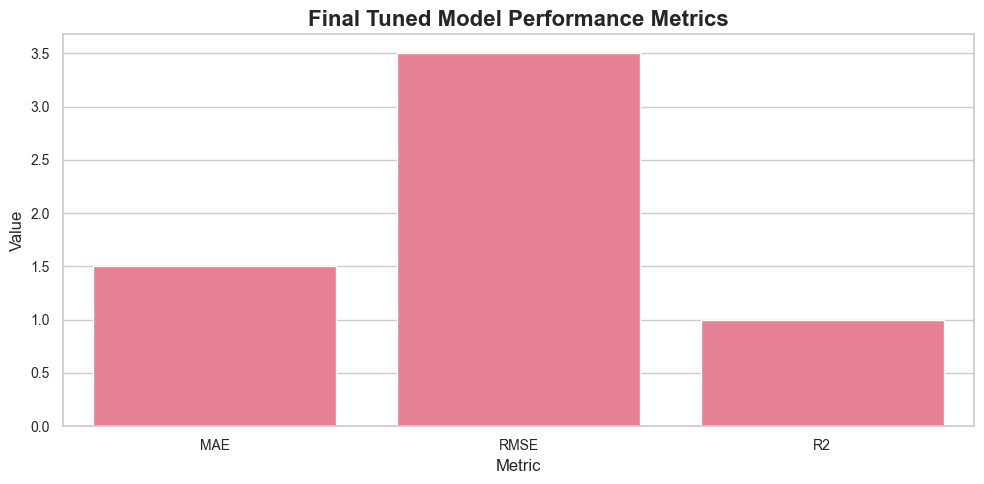

In [15]:
# Plot final model metrics

plt.figure(figsize=(10, 5))

sns.barplot(
    data=final_metrics,
    x="Metric",
    y="Value"
)

plt.title("Final Tuned Model Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "final_model_metrics.png"), bbox_inches="tight")
plt.show()

### Why this step is needed

This chart provides a simple visual summary of final model performance.

### Consequences if skipped

Readers must rely only on numeric tables, which may be less intuitive for a final project summary.

# 11. Actual vs Predicted Glucose Values

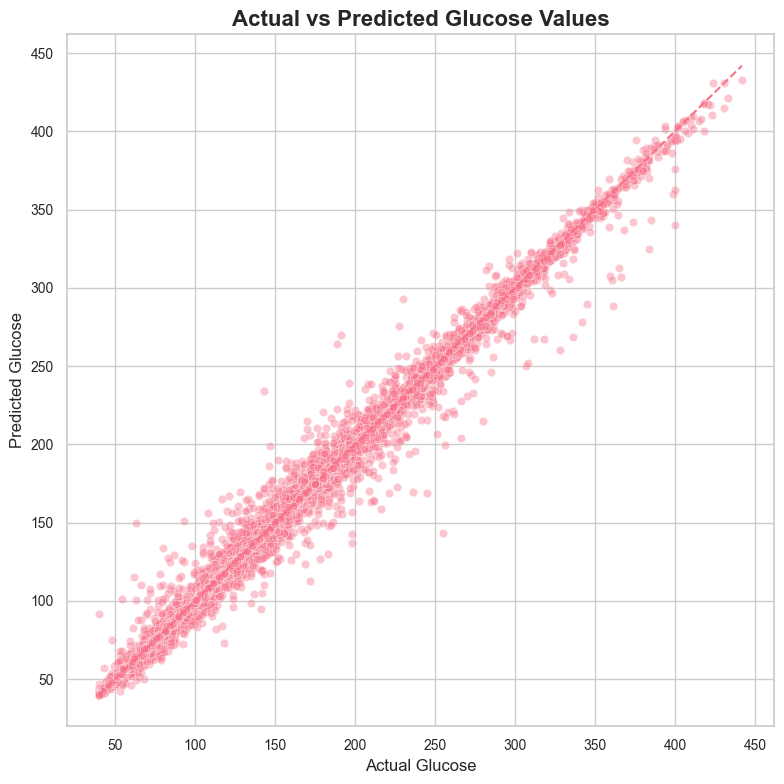

In [16]:
# Actual vs predicted scatter plot

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=pred_df,
    x="actual_glucose",
    y="predicted_glucose",
    alpha=0.4
)

min_val = min(pred_df["actual_glucose"].min(), pred_df["predicted_glucose"].min())
max_val = max(pred_df["actual_glucose"].max(), pred_df["predicted_glucose"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Actual vs Predicted Glucose Values")
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "actual_vs_predicted_glucose.png"), bbox_inches="tight")
plt.show()

### Actual vs Predicted Interpretation

This chart compares actual glucose values with predicted glucose values.

Points close to the diagonal line indicate accurate predictions.

Points far from the diagonal line indicate larger prediction errors.

If the model performs well, most points should cluster around the diagonal line.

If the points are widely scattered, the model may have difficulty capturing glucose variation.

### Why this step is needed

Actual vs predicted plots are one of the clearest ways to visually assess regression model performance.

### Consequences if skipped

You may miss whether the model systematically underpredicts or overpredicts certain glucose ranges.

# 12. Residual Calculation

In [17]:
# Calculate residuals

pred_df["residual"] = pred_df["actual_glucose"] - pred_df["predicted_glucose"]
pred_df["absolute_error"] = pred_df["residual"].abs()

pred_df[["actual_glucose", "predicted_glucose", "residual", "absolute_error"]].head()

,actual_glucose,predicted_glucose,residual,absolute_error
0,85.333333,85.343934,-0.010600,0.010600
1,121.000000,116.526660,4.473340,4.473340
2,302.000000,301.010600,0.989400,0.989400
3,91.000000,88.024835,2.975165,2.975165
4,213.666667,216.043834,-2.377167,2.377167


### Why this step is needed

Residuals show the difference between actual and predicted values.

Residual = Actual Glucose - Predicted Glucose

Positive residuals mean the model underpredicted glucose.

Negative residuals mean the model overpredicted glucose.

### Consequences if skipped

You cannot analyze model error patterns in detail.

# 13. Residual Distribution

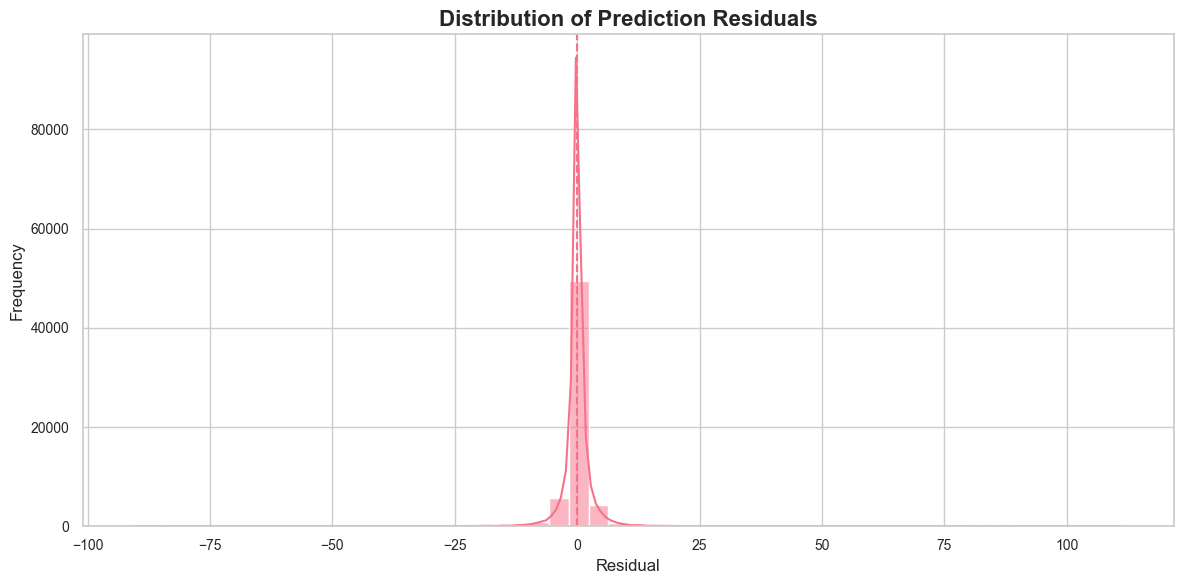

In [18]:
# Residual distribution

plt.figure(figsize=(12, 6))

sns.histplot(
    pred_df["residual"],
    bins=50,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "residual_distribution.png"), bbox_inches="tight")
plt.show()

### Residual Distribution Interpretation

A good residual distribution should be centered around zero.

If most residuals are near zero, the model is generally making small errors.

If the distribution is skewed, the model may be biased toward overprediction or underprediction.

Large tails indicate that the model sometimes makes large prediction errors.

### Why this step is needed

Residual distribution helps identify whether errors are balanced or biased.

### Consequences if skipped

You may miss systematic prediction bias in the final model.

# 14. Residuals vs Predicted Values

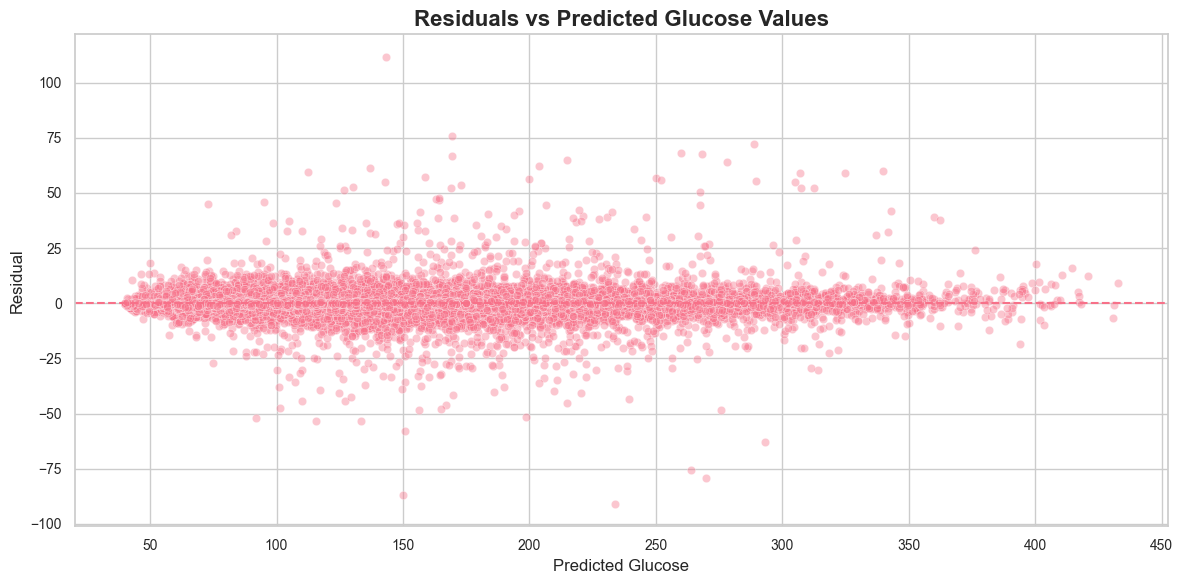

In [19]:
# Residuals vs predicted values

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=pred_df,
    x="predicted_glucose",
    y="residual",
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Glucose Values")
plt.xlabel("Predicted Glucose")
plt.ylabel("Residual")
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "residuals_vs_predicted.png"), bbox_inches="tight")
plt.show()

### Residuals vs Predicted Interpretation

This chart shows whether prediction errors change across predicted glucose ranges.

Ideally, residuals should be randomly scattered around zero.

If residuals form a pattern, the model may not be capturing some structure in the data.

If residuals become larger at high glucose values, the model may struggle more with extreme glucose levels.

# 15. Error Summary Statistics

In [20]:
# Error summary statistics

error_summary = pred_df[["residual", "absolute_error"]].describe()
error_summary

,residual,absolute_error
count,61849.000000,61849.000000
mean,0.024022,1.508096
std,3.504092,3.163044
min,-90.900460,0.000000
25%,-0.642192,0.227187
50%,-0.002980,0.646249
75%,0.651470,1.612288
max,111.754478,111.754478


In [21]:
# Error summary statistics

error_summary = pred_df[["residual", "absolute_error"]].describe()
error_summary

,residual,absolute_error
count,61849.000000,61849.000000
mean,0.024022,1.508096
std,3.504092,3.163044
min,-90.900460,0.000000
25%,-0.642192,0.227187
50%,-0.002980,0.646249
75%,0.651470,1.612288
max,111.754478,111.754478


In [22]:
# Display largest prediction errors

largest_errors = pred_df.sort_values("absolute_error", ascending=False).head(10)
largest_errors

,actual_glucose,predicted_glucose,residual,absolute_error,error_category
21933,255.0,143.245522,111.754478,111.754478,Very High Error
45652,143.0,233.900460,-90.900460,90.900460,Very High Error
12116,63.0,150.001324,-87.001324,87.001324,Very High Error
34200,191.0,270.007667,-79.007667,79.007667,Very High Error
60452,245.0,169.233933,75.766067,75.766067,Very High Error
31897,188.5,264.063365,-75.563365,75.563365,Very High Error
17439,361.0,288.623477,72.376523,72.376523,Very High Error
39172,328.0,260.015780,67.984220,67.984220,Very High Error
15364,336.0,268.381444,67.618556,67.618556,Very High Error
3587,236.0,169.248582,66.751418,66.751418,Very High Error


### Error Summary Interpretation

The error summary helps identify the average error, spread of errors, and extreme prediction mistakes.

The largest errors are important because they show cases where the model performed poorly.

In glucose prediction, large errors may be especially important because incorrect predictions during high or low glucose periods could be risky.

### Why this step is needed

This step identifies whether the model has rare but important high-error cases.

### Consequences if skipped

You may only report average performance and miss important failure cases.

# 16. Feature Importance from Final Random Forest Model

In [23]:
# Extract feature names

if "feature_name" in tuned_features.columns:
    feature_names = tuned_features["feature_name"].tolist()
else:
    feature_names = tuned_features.iloc[:, 0].tolist()

print("Number of tuned features:", len(feature_names))
feature_names

Number of tuned features: 7


['calories',
 'heart_rate',
 'glucose_lag_1',
 'glucose_lag_3',
 'glucose_lag_6',
 'glucose_rolling_30min',
 'glucose_rolling_1hr']

In [24]:
# Extract Random Forest feature importance

if hasattr(final_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    feature_importance_df.head(15)
else:
    print("The final model does not have feature_importances_.")

### Why this step is needed

Random Forest models provide feature importance values that show which variables contributed most to prediction decisions.

### Consequences if skipped

The model remains less explainable because readers cannot see which features were most influential.

# 17. Plot Feature Importance

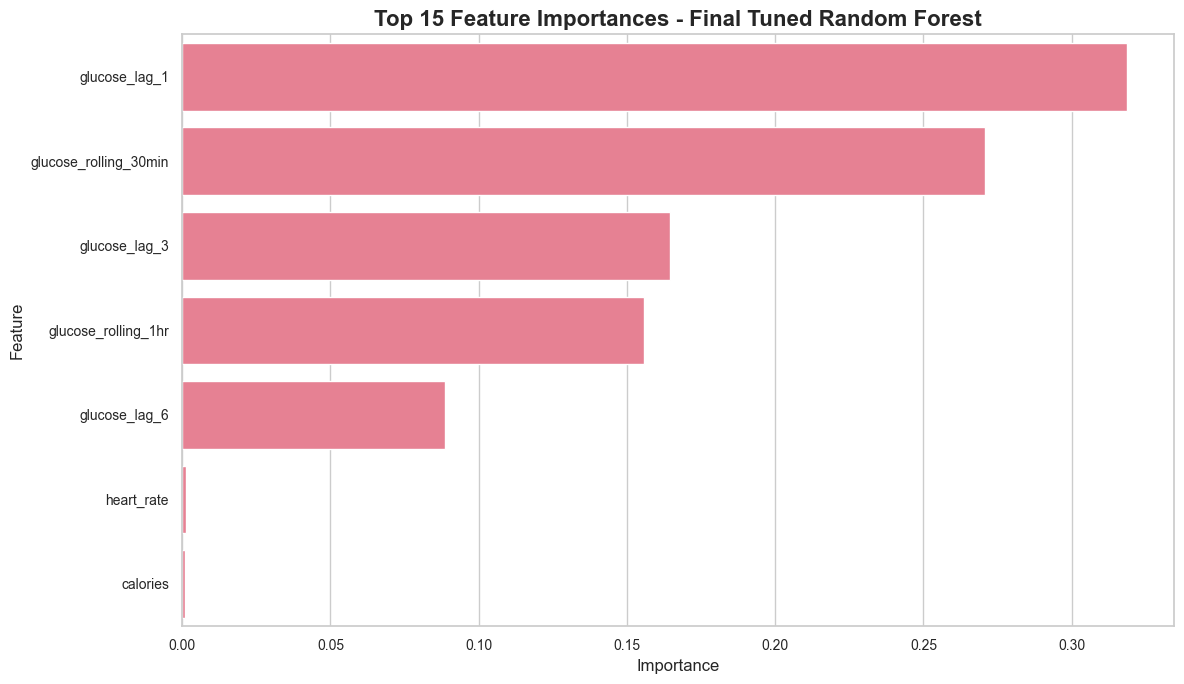

In [25]:
# Plot top feature importance values

if hasattr(final_model, "feature_importances_"):

    top_features = feature_importance_df.head(15)

    plt.figure(figsize=(12, 7))

    sns.barplot(
        data=top_features,
        x="importance",
        y="feature"
    )

    plt.title("Top 15 Feature Importances - Final Tuned Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(os.path.join(FIGURES_DIR, "final_model_feature_importance.png"), bbox_inches="tight")
    plt.show()

### Feature Importance Interpretation

The most important features are the variables the Random Forest model used most often to reduce prediction error.

If glucose lag features or rolling glucose features appear near the top, it suggests that recent glucose history is highly predictive of future glucose values.

If activity, calories, insulin, or time-based features appear lower, they may still contribute but may be less dominant than recent glucose patterns.

Feature importance does not prove causation. It only shows which features were useful for prediction.

# 18. SHAP Interpretation

In [26]:
# Optional SHAP analysis

try:
    import shap
    shap_available = True
    print("SHAP is available.")
except ImportError:
    shap_available = False
    print("SHAP is not installed. Skipping SHAP analysis.")

SHAP is available.


### Why this step is needed

SHAP helps explain how features influence individual predictions and overall model behavior.

### Consequences if skipped

The project can still be complete, but the final model interpretation will rely mostly on feature importance and residual analysis.

In [27]:
BASE_DIR = r"c:\Projects\DataAnalysis\diabetes-glucose-analysis"

# Separate directories
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
MODEL_DIR = os.path.join(BASE_DIR, "models")

print("PROCESSED_DATA_DIR:")
print(PROCESSED_DATA_DIR)

print("\nREPORTS_DIR:")
print(REPORTS_DIR)

print("\nMODEL_DIR:")
print(MODEL_DIR)

PROCESSED_DATA_DIR:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\processed

REPORTS_DIR:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports

MODEL_DIR:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\models


In [28]:
print(os.path.exists(PROCESSED_DATA_DIR))
print(os.path.exists(REPORTS_DIR))
print(os.path.exists(MODEL_DIR))

True
True
True


In [29]:
print(os.listdir(PROCESSED_DATA_DIR))

['diabetes_glucose_processed.csv', 'modeling_feature_list.csv', 'modeling_ready_dataset.csv', 'patient_summary.csv']


In [30]:
print(os.listdir(REPORTS_DIR))

['baseline_best_model_predictions.csv', 'baseline_model_feature_list.csv', 'baseline_model_results.csv', 'figures', 'final_report.md', 'tuned_model_feature_list.csv', 'tuned_model_predictions.csv', 'tuned_model_results.csv']


In [31]:
modeling_data_path = os.path.join(
    PROCESSED_DATA_DIR,
    "modeling_ready_dataset.csv"
)

modeling_df = pd.read_csv(modeling_data_path)

print(modeling_df.shape)

(309242, 21)


In [32]:
tuned_results_path = os.path.join(REPORTS_DIR, "tuned_model_results.csv")

tuned_predictions_path = os.path.join(
    REPORTS_DIR,
    "tuned_model_predictions.csv"
)

tuned_feature_list_path = os.path.join(
    REPORTS_DIR,
    "tuned_model_feature_list.csv"
)

In [33]:
model_path = os.path.join(
    MODEL_DIR,
    "final_tuned_random_forest_model.pkl"
)

In [34]:
# Prepare smaller SHAP sample for faster computation

if shap_available:

    X = modeling_df[feature_names].copy()

    # Smaller sample for faster SHAP computation
    shap_sample = X.sample(
        n=min(50, len(X)),
        random_state=42
    )

    print("SHAP sample shape:", shap_sample.shape)

SHAP sample shape: (50, 7)


In [35]:
# Calculate SHAP values faster

if shap_available:
    explainer = shap.TreeExplainer(final_model)

    shap_values = explainer.shap_values(shap_sample)

    print("SHAP values calculated successfully.")

SHAP values calculated successfully.


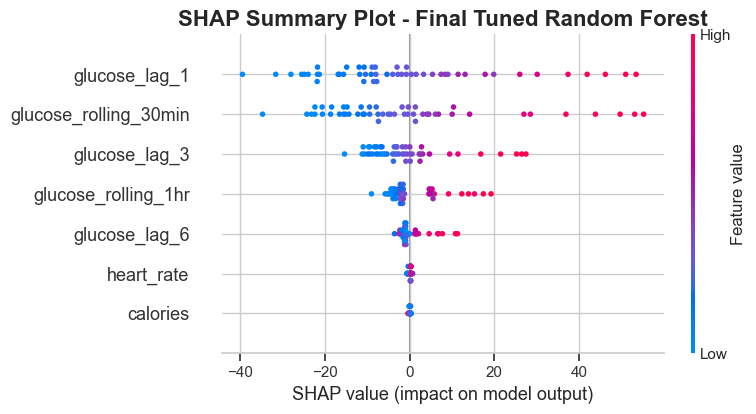

In [36]:
# SHAP summary plot

if shap_available:
    shap.summary_plot(
        shap_values,
        shap_sample,
        show=False
    )

    plt.title("SHAP Summary Plot - Final Tuned Random Forest")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "shap_summary_plot.png"), bbox_inches="tight")
    plt.show()

### SHAP Interpretation

The SHAP summary plot shows both feature importance and direction of impact.

Features at the top have the strongest influence on predictions.

Each point represents one observation.

The color usually represents whether the feature value is high or low.

SHAP values to the right increase the predicted glucose value.

SHAP values to the left decrease the predicted glucose value.

If glucose lag or rolling glucose features dominate the SHAP plot, it confirms that recent glucose history is one of the strongest predictors.

# 19. Compare Tuned Model Results Table

In [37]:
# Review tuned model results

tuned_results

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593
2,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
3,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593
4,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199
5,RandomizedSearchCV Random Forest - Test,1.731706,3.649768,0.995909
6,Tuned Random Forest with Selected Features - T...,0.759631,1.465263,0.999341
7,Tuned Random Forest with Selected Features - Test,1.508096,3.504146,0.996229


In [38]:
# Sort results if common metric columns exist

metric_cols = tuned_results.columns.tolist()

if "RMSE" in metric_cols:
    tuned_results_sorted = tuned_results.sort_values("RMSE", ascending=True)
elif "MAE" in metric_cols:
    tuned_results_sorted = tuned_results.sort_values("MAE", ascending=True)
else:
    tuned_results_sorted = tuned_results.copy()

tuned_results_sorted

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
2,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
6,Tuned Random Forest with Selected Features - T...,0.759631,1.465263,0.999341
4,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199
7,Tuned Random Forest with Selected Features - Test,1.508096,3.504146,0.996229
5,RandomizedSearchCV Random Forest - Test,1.731706,3.649768,0.995909
3,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593


### Tuned Model Comparison Interpretation

The tuned model results table summarizes the performance of models or tuning approaches tested in Notebook 6.

The best model should generally have lower MAE and RMSE and higher R².

However, the final model should not be selected only by one metric. Stability, overfitting behavior, interpretability, and practical usefulness should also be considered.

## 20. Final Model Strengths

The final tuned Random Forest model has several strengths:

- It can capture non-linear relationships in glucose patterns.
- It uses recent glucose history through lag and rolling features.
- It performs better than a simple baseline model if tuning improved the evaluation metrics.
- It provides feature importance values for interpretation.
- It can handle complex interactions between time, activity, insulin, and glucose-related features.

These strengths make the model useful for understanding which variables are most predictive of glucose values in this dataset.

## 21. Final Model Limitations

Although the final tuned model provides useful predictive performance, it has important limitations:

### Dataset limitations

The dataset contains a limited number of patients, so the model may not generalize well to a broader population.

### Time-series dependency

Glucose values are time-dependent. Random train-test splitting may produce optimistic results if nearby time points appear in both training and testing data.

### Patient-level generalization

A model may perform well on known patients but perform worse on completely unseen patients.

### Feature limitations

Important real-world factors such as meal composition, stress, sleep, illness, medication timing, and insulin sensitivity may not be fully captured.

### Clinical limitations

This model is for analysis and learning purposes only. It should not be used for medical decision-making without clinical validation.

### Interpretability limitations

Random Forest models are more interpretable than some advanced models, but they are still not as transparent as simple linear models.

Feature importance and SHAP values help explain the model, but they do not prove causal relationships.

## 22. Business and Research Conclusions

This project shows that glucose prediction can be improved by combining cleaned time-series data, engineered features, and tuned machine learning models.

The most important insight is that recent glucose history is likely one of the strongest predictors of future glucose values.

Lag features and rolling glucose features help the model understand short-term glucose trends.

Time-based, activity-related, insulin-related, and nutrition-related features may provide additional useful information, but their importance depends on data quality and completeness.

From a research perspective, the project demonstrates a complete machine learning workflow:

- Data understanding
- Data cleaning
- Exploratory data analysis
- Feature engineering
- Baseline modeling
- Hyperparameter tuning
- Final model interpretation
- Project documentation

From a practical perspective, the model may help identify patterns in glucose behavior, but further validation is required before considering any real-world health application.

## 23. Final Project Summary

The diabetes-glucose-analysis project used the HUPA-UCM Diabetes Dataset to build a machine learning workflow for glucose prediction.

The project began with data understanding, where patient files, columns, data types, missing values, and time ranges were reviewed.

Next, the data was cleaned and preprocessed. Multiple patient files were combined, patient identifiers were created, timestamps were converted, missing values were handled, duplicates were checked, and time-series consistency was validated.

Exploratory data analysis was then performed to understand glucose distributions, glucose categories, patient-level patterns, and relationships between glucose and other features.

Feature analysis and modeling preparation created lag features, rolling glucose features, time-based variables, and final modeling datasets.

Baseline modeling compared regression models such as Linear Regression, Decision Tree Regression, and Random Forest Regression using MAE, RMSE, and R².

Model improvement and hyperparameter tuning used cross-validation, GridSearchCV, RandomizedSearchCV, Random Forest tuning, feature selection, and advanced evaluation.

The final tuned Random Forest model was saved and interpreted in this notebook using performance metrics, actual vs predicted plots, residual analysis, feature importance, and optional SHAP analysis.

Overall, the project demonstrates a professional end-to-end data analysis and machine learning workflow suitable for GitHub and portfolio presentation.

# 24. Save Final Interpretation Outputs

In [39]:
# Save final metrics

final_metrics_path = os.path.join(DATA_DIR, "final_model_metrics.csv")
final_metrics.to_csv(final_metrics_path, index=False)

# Save final predictions with residuals

final_predictions_path = os.path.join(DATA_DIR, "final_model_predictions_with_residuals.csv")
pred_df.to_csv(final_predictions_path, index=False)

# Save feature importance if available

if hasattr(final_model, "feature_importances_"):
    feature_importance_path = os.path.join(DATA_DIR, "final_model_feature_importance.csv")
    feature_importance_df.to_csv(feature_importance_path, index=False)

print("Final interpretation outputs saved successfully.")
print(final_metrics_path)
print(final_predictions_path)

if hasattr(final_model, "feature_importances_"):
    print(feature_importance_path)

Final interpretation outputs saved successfully.
c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports\final_model_metrics.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports\final_model_predictions_with_residuals.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports\final_model_feature_importance.csv


### Why this step is needed

Saving final interpretation outputs makes the results reusable for the README, reports, presentations, and future analysis.

### Consequences if skipped

Important final results would exist only inside the notebook and may be harder to reference later.

## 27. Final Notebook Conclusion

This notebook completed the final interpretation phase of the diabetes glucose prediction project.

The final tuned Random Forest model was evaluated using MAE, RMSE, and R².

Actual vs predicted plots were used to visually assess prediction quality.

Residual analysis was used to identify model error patterns.

Feature importance and optional SHAP analysis were used to explain which features influenced predictions.

The project findings suggest that recent glucose history, especially lag and rolling glucose features, plays an important role in predicting glucose values.

The project is now ready for final README updates and GitHub presentation.

## Final Project Review Checklist

Before publishing this project to GitHub, the following checks were completed:

- All notebooks run from top to bottom without errors
- Notebook outputs were reviewed and cleaned
- Final datasets were saved in the correct folders
- Baseline and tuned model results were saved
- Final model predictions were saved
- Final trained model file was saved
- Feature list was saved
- README was updated with project goal, workflow, findings, limitations, and future work
- Repository folders were organized professionally
- requirements.txt was prepared
- .gitignore was prepared
- Streamlit dashboard was created
- Final GitHub push was completed